# Hyperconvolution Playground
## 2×2 Experiment: Architecture × Augmentation
### Jackson2020 → Danenberg2022 (cross-dataset generalisation)

| Condition | Architecture | Augmented |
|-----------|-------------|-----------|
| `no_pca`        | Conv2d(K, 64, 7×7) — marker-agnostic | No  |
| `no_pca_aug`    | Conv2d(K, 64, 7×7) — marker-agnostic | Yes |
| `hyperconv`     | MarkerStem — shared embeddings across tasks | No  |
| `hyperconv_aug` | MarkerStem — shared embeddings across tasks | Yes |

**Goal**: show that (a) marker-aware kernels (hyperconv) improve over a fixed conv1, and (b) data augmentation further improves training — two orthogonal improvements testable in a single run.

**Multi-task joint training**: each condition trains **one model** on all 11 marker-prediction tasks simultaneously. Each training sample is a `(file, task)` pair; the model sees different `marker_ids` each batch. This is the correct ImmuVis evaluation: shared embeddings are updated by all task combinations, so the model genuinely learns marker semantics rather than fitting a single fixed panel.

- `no_pca`: marker-agnostic baseline — receives K=10 sorted channels, no identity info.  
- `hyperconv`: same K=10 channels but with per-batch `marker_ids`; shared `MarkerStem` embeddings must generalise across all task configurations.

**Parameter matching**: `embed_dim` auto-computed as `round(K × 3136 / (vocab_size + 3136))` so hyperconv and no_pca stems have the same parameter budget.

**Augmentation (training only)**: random H/V flips · random 90° rotation · random crop (75–100%). Applied jointly to input x and target y to preserve spatial correspondence. Val and test sets are never augmented.

**Preprocessing**: one regression + z-score fit per channel (not per task), cached before the conditions loop. 4 training runs total (not 44).

In [1]:
!pip install pytorch_msssim imagecodecs torchmetrics clean-fid optuna
!pip install --force-reinstall "numpy>=1.26.0,<2.1.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 79.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2

In [2]:
import os, tifffile, tempfile, pickle, json, imageio, shutil
import numpy as np
import pandas as pd
import gc, time, glob, random
from scipy.stats import pearsonr
from sklearn.decomposition import IncrementalPCA
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import KFold

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.parametrizations import weight_norm
from torch.utils.data import DataLoader, random_split, Dataset
from torch.amp import GradScaler, autocast
from torchvision import models
import skimage.transform
from pytorch_msssim import ms_ssim
from cleanfid import fid
import optuna
from optuna.trial import Trial

import matplotlib.pyplot as plt
params = {
    'legend.fontsize': 16, 'figure.figsize': (16, 10),
    'axes.labelsize': 16,  'axes.titlesize': 12,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'figure.titlesize': 30,
}
plt.rcParams.update(params)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# ── KAGGLE RESUME SETUP ──────────────────────────────────────────────────────
# Training saves checkpoints to /kaggle/working/cv_cache every epoch AND pushes
# them to a Kaggle dataset (KAGGLE_DATASET) so they survive session crashes.
#
# One-time setup:
#   1. Kaggle notebook → Add-ons → Secrets: add KAGGLE_USERNAME and KAGGLE_KEY
#      (get the key from kaggle.com → Account → Create New Token).
#   2. First run creates the dataset automatically on the first epoch push.
#   3. After a crash: Notebook → Settings → Datasets → add
#      "<your-username>/your-notebook-output-files" as an input dataset.
#      Re-run — Cell 4 copies the files back and training resumes automatically.
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CACHE_ROOT = "/kaggle/input/your-notebook-output-files/cv_cache"
WORK_CACHE_ROOT  = "/kaggle/working/cv_cache"

# Push config — increase KAGGLE_PUSH_EVERY_N to reduce API calls (e.g. push every 2 epochs)
KAGGLE_DATASET       = "your-notebook-output-files"
KAGGLE_PUSH_ENABLED  = os.path.exists("/kaggle/working")   # auto-detects Kaggle environment
KAGGLE_PUSH_EVERY_N  = 1                                   # push every N epochs

if os.path.exists(INPUT_CACHE_ROOT):
    os.makedirs(WORK_CACHE_ROOT, exist_ok=True)
    for src in glob.glob(os.path.join(INPUT_CACHE_ROOT, "**/*"), recursive=True):
        if os.path.isfile(src):
            dst = src.replace(INPUT_CACHE_ROOT, WORK_CACHE_ROOT, 1)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy2(src, dst)
    print(f"[init] Restored cache from {INPUT_CACHE_ROOT} -> {WORK_CACHE_ROOT}")
else:
    os.makedirs(WORK_CACHE_ROOT, exist_ok=True)
    print("No previous cache found; starting fresh.")

No previous cache found; starting fresh.


In [4]:
# ── Proof-of-Concept speed mode ───────────────────────────────────────────────
# Set POC_MODE = True to sweep all 4 conditions quickly on Kaggle (T4×2, 12 h).
# Set POC_MODE = False to restore full training.
POC_MODE = True

poc_cfg = dict(
    epochs      = 10,
    patience    = 3,
    lr_patience = 3,
    batch_size  = 8,
    num_workers = 2,
)

## Model Architectures
### Standard (`no_pca`): `ResNetUNet` — `ResNet50Encoder` + `UNetDecoder`
### Hyperconv (`hyperconv`): `ResNetHyperUNet` — `ResNet50HyperEncoder` + `UNetDecoder`
- `MarkerStem`: replaces `conv1+bn1+relu`; a single linear layer maps each marker's embedding → (64, 1, 7, 7) kernel; K per-marker convolutions summed → 64-ch output
- `ResNet50HyperEncoder`: `MarkerStem` + pretrained ResNet50 (layer1 frozen, layers 2–4 fine-tuned)
- `marker_ids` stored as a buffer in `ResNetHyperUNet` — `forward(x)` signature identical to `ResNetUNet`
- **Decoder is shared** — `UNetDecoder` is unchanged across all conditions

In [5]:
# ─── Shared building blocks (used by all conditions) ─────────────────────────

class ResNet50Encoder(nn.Module):
    def __init__(self, in_channels=3, pretrained_conv1=False):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        if pretrained_conv1 and in_channels == 3:
            self.conv1 = backbone.conv1
        else:
            self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        for param in backbone.parameters():
            param.requires_grad = False
        # re-enable conv1 after the freeze loop if using pretrained weights
        if pretrained_conv1 and in_channels == 3:
            for param in self.conv1.parameters():
                param.requires_grad = True
        for param in self.layer2.parameters():
            param.requires_grad = True
        for param in self.layer3.parameters():
            param.requires_grad = True
        for param in self.layer4.parameters():
            param.requires_grad = True

    def forward(self, x):
        f0 = self.relu(self.bn1(self.conv1(x)))
        f0_pool = self.maxpool(f0)
        f1 = self.layer1(f0_pool)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)
        return f0, f1, f2, f3, f4


class UNetDecoder(nn.Module):
    def __init__(self, out_channels=1, p=0.2):
        super().__init__()
        self.conv4_1 = nn.Sequential(
            nn.Conv2d(2048+1024, 1024, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True), nn.Dropout2d(p))
        self.conv4_2 = nn.Sequential(
            nn.Conv2d(1024, 1024, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True))
        self.conv3_1 = nn.Sequential(
            nn.Conv2d(1024+512, 512, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.Dropout2d(p))
        self.conv3_2 = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True))
        self.conv2_1 = nn.Sequential(
            nn.Conv2d(512+256, 256, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(p))
        self.conv2_2 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.conv1_1 = nn.Sequential(
            nn.Conv2d(256+256+64, 64, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(p))
        self.conv1_2 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.final_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.up0 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1, padding_mode='reflect', bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.final = weight_norm(nn.Conv2d(32, out_channels, 1))

    def forward(self, skips):
        f0, f1, f2, f3, f4 = skips
        x = F.interpolate(f4, scale_factor=2, mode='bilinear', align_corners=False)
        if x.shape[-2:] != f3.shape[-2:]:
            f3 = F.interpolate(f3, size=x.shape[-2:], mode='bilinear', align_corners=False)
        x = self.conv4_2(self.conv4_1(torch.cat([x, f3], 1)))
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        if x.shape[-2:] != f2.shape[-2:]:
            f2 = F.interpolate(f2, size=x.shape[-2:], mode='bilinear', align_corners=False)
        x = self.conv3_2(self.conv3_1(torch.cat([x, f2], 1)))
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        if x.shape[-2:] != f1.shape[-2:]:
            f1 = F.interpolate(f1, size=x.shape[-2:], mode='bilinear', align_corners=False)
        x = self.conv2_2(self.conv2_1(torch.cat([x, f1], 1)))
        if f0.shape[-2:] != f1.shape[-2:]:
            f0 = F.interpolate(f0, size=f1.shape[-2:], mode='bilinear', align_corners=False)
        x = self.conv1_2(self.conv1_1(torch.cat([x, f1, f0], 1)))
        x = F.interpolate(self.up0(self.final_up(x)), scale_factor=2, mode='bilinear', align_corners=False)
        return torch.sigmoid(self.final(x))


class ResNetUNet(nn.Module):
    def __init__(self, in_channels=3, pretrained_conv1=False):
        super().__init__()
        self.encoder = ResNet50Encoder(in_channels=in_channels, pretrained_conv1=pretrained_conv1)
        self.decoder = UNetDecoder()

    def forward(self, x, marker_ids=None):   # marker_ids ignored — marker-agnostic baseline
        return self.decoder(self.encoder(x))


# ─── Hyperconv encoder (ImmuVis-style, arxiv:2602.04585) ─────────────────────
#
# MarkerStem replaces conv1 with per-marker (64, 1, 7×7) kernels generated by
# a single linear layer from learned marker embeddings. embed_dim is chosen so
# that the total stem parameter count matches the no_pca Conv2d(K, 64, 7×7).
#
# Parameter budget:
#   no_pca:    K × 64 × 49  params (direct kernel weights)
#   hyperconv: vocab × e + e × 64 × 49  params  where e = round(K×3136/(vocab+3136))
# → both stems have essentially the same capacity.
#
# In multi-task training, marker_ids is passed PER BATCH (not stored as a fixed
# buffer), so shared embeddings are updated by all 11 task configurations jointly.

class MarkerStem(nn.Module):
    """
    Input stem that generates Conv2d kernels from learned marker embeddings.
    Each of the K input channels gets its own (out_ch, 1, 7, 7) kernel via a
    single linear projection of its marker embedding; results are summed →
    (B, 64, H/2, W/2), same shape as ResNet50 conv1 output.
    """
    def __init__(self, marker_vocab_size: int, embed_dim: int, out_ch: int = 64):
        super().__init__()
        self.out_ch     = out_ch
        self.embeddings = nn.Embedding(marker_vocab_size, embed_dim)
        self.hypernet   = nn.Linear(embed_dim, out_ch * 7 * 7, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor, marker_ids: torch.Tensor) -> torch.Tensor:
        # x: (B, K, H, W),  marker_ids: (B, K) or (K,) — vocabulary indices
        if marker_ids.dim() == 1:
            marker_ids = marker_ids.unsqueeze(0).expand(x.shape[0], -1)
        # Use first sample's ids to generate kernels (all samples in a batch share the same task)
        ids     = marker_ids[0]                                        # (K,)
        K       = x.shape[1]
        embs    = self.embeddings(ids)                                 # (K, embed_dim)
        kernels = self.hypernet(embs).view(K, self.out_ch, 1, 7, 7)   # (K, 64, 1, 7, 7)
        out = sum(
            F.conv2d(x[:, k:k+1], kernels[k], padding=3, stride=2)
            for k in range(K)
        )                                                              # (B, 64, H/2, W/2)
        return self.relu(self.bn(out))


class ResNet50HyperEncoder(nn.Module):
    """ResNet50 encoder with conv1+bn1+relu replaced by MarkerStem."""
    def __init__(self, marker_vocab_size: int, embed_dim: int):
        super().__init__()
        backbone     = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.stem    = MarkerStem(marker_vocab_size, embed_dim, out_ch=64)
        self.maxpool = backbone.maxpool
        self.layer1  = backbone.layer1
        self.layer2  = backbone.layer2
        self.layer3  = backbone.layer3
        self.layer4  = backbone.layer4
        for param in backbone.parameters():
            param.requires_grad = False
        for param in self.layer2.parameters():
            param.requires_grad = True
        for param in self.layer3.parameters():
            param.requires_grad = True
        for param in self.layer4.parameters():
            param.requires_grad = True

    def forward(self, x: torch.Tensor, marker_ids: torch.Tensor):
        f0      = self.stem(x, marker_ids)   # (B, 64, H/2, W/2)
        f0_pool = self.maxpool(f0)
        f1 = self.layer1(f0_pool)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)
        return f0, f1, f2, f3, f4


class ResNetHyperUNet(nn.Module):
    """
    ResNetUNet with MarkerStem replacing the encoder's conv1+bn1+relu.
    In multi-task training, marker_ids is passed per forward call (varies per batch).
    The stored buffer is a fallback default only.
    """
    def __init__(self, marker_vocab_size: int, embed_dim: int, default_marker_ids: torch.Tensor):
        super().__init__()
        self.encoder = ResNet50HyperEncoder(marker_vocab_size, embed_dim)
        self.decoder = UNetDecoder()
        self.register_buffer('marker_ids', default_marker_ids)

    def forward(self, x: torch.Tensor, marker_ids: torch.Tensor = None) -> torch.Tensor:
        ids = marker_ids if marker_ids is not None else self.marker_ids
        return self.decoder(self.encoder(x, ids))

## Preprocessing
`fit_preprocessing(use_pca=True)` → regression → arcsinh → PCA (3D) → z-score (structural markers)  
`fit_preprocessing(use_pca=False)` → regression → arcsinh → per-channel z-score (immune markers)

In [6]:
def to_hwc(img):
    if img.ndim == 2:
        img = img[..., None]
    if img.shape[0] < img.shape[1] and img.shape[0] < img.shape[2]:
        img = np.transpose(img, (1, 2, 0))
    return img.astype(np.float32, copy=False)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def fit_channel_preprocessing(train_files, pred_channel_indices, control_indices,
                               cofactor=5.0, eps=1e-8, sample_per_file=50_000):
    """
    Fit per-channel preprocessing shared across all marker-prediction tasks.

    Returns:
      channel_preproc:   {ch_idx: (reg_model, float mean, float std)}
                         Residual z-score stats for input channels.
      target_norm_stats: {ch_idx: (float p01, float p99)}
                         Training-set 1st/99th arcsinh percentiles for target
                         normalisation.  Using global stats preserves absolute
                         intensity differences across images (per-image min-max
                         would erase them).
    """
    if not train_files:
        raise ValueError(
            "fit_channel_preprocessing: train_files is empty.\n"
            "Check that the dataset path is correct and contains .tif/.tiff files.\n"
            "On Kaggle, files may live in a subdirectory — the glob in cell 13 now "
            "searches recursively, so re-run that cell first."
        )

    reg_models = {j: SGDRegressor(max_iter=1000, tol=1e-3) for j in pred_channel_indices}
    n_ctrl = len(control_indices)

    # Pass 1: fit regression (control markers → prediction channel)
    for c, f in enumerate(train_files):
        if c % max(1, len(train_files) // 4) == 0 or c == len(train_files) - 1:
            print(f'[prepro] regression pass: {c+1}/{len(train_files)}')
        img = to_hwc(tifffile.imread(f))
        Xc  = img[..., control_indices].reshape(-1, n_ctrl)
        for j in pred_channel_indices:
            reg_models[j].partial_fit(Xc, img[..., j].reshape(-1))
        del img, Xc; gc.collect()

    # Pass 2: residual arcsinh z-score stats + raw arcsinh samples for percentiles
    sums        = {j: 0.  for j in pred_channel_indices}
    sq          = {j: 0.  for j in pred_channel_indices}
    cnt         = {j: 0   for j in pred_channel_indices}
    arc_samples = {j: []  for j in pred_channel_indices}

    for c, f in enumerate(train_files):
        if c % max(1, len(train_files) // 4) == 0 or c == len(train_files) - 1:
            print(f'[prepro] stats pass: {c+1}/{len(train_files)}')
        img = to_hwc(tifffile.imread(f))
        Xc  = img[..., control_indices].reshape(-1, n_ctrl)
        N   = Xc.shape[0]
        for j in pred_channel_indices:
            raw = img[..., j].reshape(-1)
            r = np.arcsinh((raw - reg_models[j].predict(Xc)) / cofactor)
            sums[j] += r.sum(); sq[j] += (r * r).sum(); cnt[j] += N
            raw_arc = np.arcsinh(raw / cofactor)
            idx = np.random.choice(N, min(sample_per_file, N), replace=False)
            arc_samples[j].append(raw_arc[idx])
        del img, Xc; gc.collect()

    channel_preproc   = {}
    target_norm_stats = {}
    for j in pred_channel_indices:
        n = cnt[j]
        if n == 0:
            raise RuntimeError(
                f"fit_channel_preprocessing: channel {j} has 0 accumulated pixels — "
                "this should not happen if train_files is non-empty."
            )
        m = sums[j] / n
        s = float(np.sqrt(max(sq[j] / n - m ** 2, 0))) + eps
        channel_preproc[j] = (reg_models[j], float(m), s)
        all_arc = np.concatenate(arc_samples[j])
        target_norm_stats[j] = (float(np.percentile(all_arc, 1)),
                                float(np.percentile(all_arc, 99)))

    print(f'[prepro] fitted {len(channel_preproc)} channels; '
          f'target ranges: { {j: (f"{p01:.2f}", f"{p99:.2f}") for j, (p01,p99) in target_norm_stats.items()} }')
    return channel_preproc, target_norm_stats


def preprocess_multi(file_path, target_idx, input_channels, channel_preproc,
                     target_norm_stats, control_indices, cofactor=5.0, index_map=None):
    """
    Load one image and return:
      x: (K, H, W) — arcsinh-z-scored residuals for input_channels
      y: (1, H, W) — arcsinh globally normalised target, clipped to [0, 1]

    target_idx and keys in target_norm_stats are Jackson-space indices.
    index_map remaps them to the actual channel positions in file_path (used for
    Danenberg test images where channel order differs from Jackson training data).
    """
    img = to_hwc(tifffile.imread(file_path))
    H, W, _ = img.shape

    def _r(i):
        return index_map[i] if index_map is not None else i

    # Target: arcsinh → global percentile normalisation → clip [0,1]
    y_arc = np.arcsinh(img[..., _r(target_idx)] / cofactor).astype(np.float32)
    p01, p99 = target_norm_stats[target_idx]
    y = torch.from_numpy(
        np.clip((y_arc - p01) / (p99 - p01 + 1e-8), 0., 1.)
    ).unsqueeze(0).float()

    # Inputs: regression residuals → arcsinh → channel z-score
    n_ctrl = len(control_indices)
    Xc     = img[..., [_r(i) for i in control_indices]].reshape(-1, n_ctrl)
    chans  = []
    for j in input_channels:
        reg, m, s = channel_preproc[j]
        r = np.arcsinh((img[..., _r(j)].reshape(-1) - reg.predict(Xc)) / cofactor)
        chans.append(((r - m) / (s + 1e-8)).reshape(H, W).astype(np.float32))

    x = torch.from_numpy(np.stack(chans, 0)).float()
    return x, y


def augment_pair(x: torch.Tensor, y: torch.Tensor):
    """
    Apply an identical random spatial transform to input x (K,H,W) and target y (1,H,W).
    Flips, 90° rotations, and random crop — no intensity changes so z-scored residuals
    stay calibrated. Pure torch ops, no new dependencies.
    """
    K  = x.shape[0]
    xy = torch.cat([x, y], dim=0)          # (K+1, H, W) — joint spatial transform

    if random.random() < 0.5:
        xy = xy.flip(-1)                   # horizontal flip
    if random.random() < 0.5:
        xy = xy.flip(-2)                   # vertical flip

    k = random.randint(0, 3)
    if k:
        xy = torch.rot90(xy, k, [-2, -1])  # 90° / 180° / 270° rotation

    _, H, W = xy.shape
    ch   = random.randint(max(64, int(H * 0.75)), H)
    cw   = random.randint(max(64, int(W * 0.75)), W)
    top  = random.randint(0, H - ch)
    left = random.randint(0, W - cw)
    xy   = xy[:, top:top+ch, left:left+cw]

    return xy[:K], xy[K:]


def pad_collate(batch):
    X_list, Y_list, ids_list, orig = zip(*batch)
    maxH = max(x.shape[1] for x in X_list)
    maxW = max(x.shape[2] for x in X_list)
    Xp  = torch.stack([F.pad(x, (0, maxW-x.shape[2], 0, maxH-x.shape[1])) for x in X_list])
    Yp  = torch.stack([F.pad(y, (0, maxW-y.shape[2], 0, maxH-y.shape[1])) for y in Y_list])
    ids = torch.stack(ids_list)   # (B, K)
    return Xp, Yp, ids, orig

In [7]:
# ─── Dataset ──────────────────────────────────────────────────────────────────

class MultiTaskDataset(Dataset):
    """
    Expands to len(file_list) × len(tasks) items.  Each item is a (file, task) pair
    that yields (x, y, marker_ids, (H, W)) where:
      x:          (K, H, W)  arcsinh-z-scored input channels
      y:          (1, H, W)  arcsinh globally-normalised target (no per-image rescaling)
      marker_ids: (K,)       Jackson vocabulary indices of the K input channels
      (H, W):                original spatial size before any padding

    tasks: list of (target_idx, input_channels_sorted) tuples — one per marker.
    Input channels are sorted by Jackson index so no_pca channel positions are
    consistent across tasks.

    Val/test datasets are constructed with augment=False.
    File-level train/val split is handled externally via Subset on file indices.
    """
    def __init__(self, file_list, tasks, channel_preproc, target_norm_stats,
                 control_indices, cofactor=5.0, augment=False, index_map=None):
        self.file_list        = file_list
        self.tasks            = tasks
        self.channel_preproc  = channel_preproc
        self.target_norm_stats = target_norm_stats
        self.control_indices  = control_indices
        self.cofactor         = cofactor
        self.augment          = augment
        self.index_map        = index_map
        self.items = [(fi, ti)
                      for fi in range(len(file_list))
                      for ti in range(len(tasks))]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        fi, ti = self.items[idx]
        target_idx, input_channels = self.tasks[ti]
        x, y = preprocess_multi(
            self.file_list[fi], target_idx, input_channels,
            self.channel_preproc, self.target_norm_stats,
            self.control_indices, self.cofactor, self.index_map,
        )
        if self.augment:
            x, y = augment_pair(x, y)
        return x, y, torch.tensor(input_channels, dtype=torch.long), (x.shape[1], x.shape[2])

In [8]:
# ─── Training helpers ─────────────────────────────────────────────────────────

import math

def smart_load_state_dict(model, state, strict=True):
    is_dp      = isinstance(model, nn.DataParallel)
    has_module = all(k.startswith('module.') for k in state.keys())
    if is_dp and not has_module:
        return model.module.load_state_dict(state, strict=strict)
    if not is_dp and has_module:
        state = {k.replace('module.', '', 1): v for k, v in state.items()}
    return (model.module if is_dp else model).load_state_dict(state, strict=strict)


def train_model(model, train_loader, val_loader, device, title, config,
                epochs=30, huber_beta=1.0, grad_clip=1.0, use_amp=True,
                patience=8, save_path='best_model.pth', lr_patience=5):
    model.to(device)
    lr, alpha = config['lr'], config['alpha']
    opt    = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=lr_patience)
    scaler = GradScaler(enabled=use_amp)
    eps    = 1e-8

    train_losses, val_losses = [], []
    best_val, best_epoch, no_improve = float('inf'), None, 0
    start_epoch = 0

    # ── Epoch-level resume ────────────────────────────────────────────────────
    resume_path = (save_path + '_resume.pkl') if save_path else None
    done_path   = (save_path + '_done')       if save_path else None

    if resume_path and os.path.exists(resume_path) \
            and save_path and os.path.exists(save_path):
        ckpt = torch.load(resume_path, map_location=device)
        model.load_state_dict(torch.load(save_path, map_location=device))
        opt.load_state_dict(ckpt['opt_state'])
        sched.load_state_dict(ckpt['sched_state'])
        scaler.load_state_dict(ckpt['scaler_state'])
        start_epoch  = ckpt['epoch'] + 1
        train_losses = ckpt['train_losses']
        val_losses   = ckpt['val_losses']
        best_val     = ckpt['best_val']
        best_epoch   = ckpt['best_epoch']
        no_improve   = ckpt['no_improve']
        print(f'[resume] Continuing from epoch {start_epoch} '
              f'(best val={best_val:.4f} at epoch {best_epoch})')

    for epoch in range(start_epoch, epochs):
        model.train()
        running = 0.0
        for batch_idx, (x, y, marker_ids, orig_sizes) in enumerate(train_loader):
            x          = x.to(device, non_blocking=True)
            y          = y.to(device, non_blocking=True)
            marker_ids = marker_ids.to(device, non_blocking=True)
            B = x.shape[0]
            opt.zero_grad(set_to_none=True)
            with autocast(device_type='cuda', enabled=use_amp):
                yhat = model(x, marker_ids)
                hub_parts, ssim_parts = [], []
                for i in range(B):
                    h, w = orig_sizes[i]
                    yi, yhi = y[i:i+1, :, :h, :w], yhat[i:i+1, :, :h, :w]
                    hub_parts.append(F.smooth_l1_loss(yhi, yi, beta=huber_beta))
                    ssim_parts.append(1.0 - ms_ssim(yhi, yi, data_range=1.0, win_size=7, weights=[0.4, 0.3, 0.3]))
                loss = alpha * torch.stack(hub_parts).mean() \
                     + (1-alpha) * torch.stack(ssim_parts).mean()
            scaler.scale(loss).backward()
            if grad_clip:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(opt); scaler.update()
            running += loss.item() * B
            if batch_idx % 20 == 0:
                torch.cuda.empty_cache()
        train_losses.append(running / len(train_loader.dataset))

        model.eval()
        val_running = val_n = 0
        with torch.no_grad(), autocast(device_type='cuda', enabled=use_amp):
            for x, y, marker_ids, orig_sizes in val_loader:
                x          = x.to(device, non_blocking=True)
                y          = y.to(device, non_blocking=True)
                marker_ids = marker_ids.to(device, non_blocking=True)
                B = x.shape[0]; yhat = model(x, marker_ids); skip = False
                hub_sum = ssim_sum = 0.0
                for i in range(B):
                    h, w = orig_sizes[i]
                    yi   = y[i:i+1, :, :h, :w]
                    yhi  = yhat[i:i+1, :, :h, :w].clamp(0., 1.)
                    if (yi.max()-yi.min()).abs() < eps or (yhi.max()-yhi.min()).abs() < eps:
                        skip = True; break
                    sv = ms_ssim(yhi, yi, data_range=1.0, win_size=7, weights=[0.4, 0.3, 0.3]).item()
                    hv = F.smooth_l1_loss(yhi, yi, beta=huber_beta).item()
                    if math.isnan(sv) or math.isnan(hv): skip = True; break
                    hub_sum += hv; ssim_sum += 1.0 - sv
                if not skip:
                    vl = alpha * hub_sum/B + (1-alpha) * ssim_sum/B
                    if not (math.isnan(vl) or math.isinf(vl)):
                        val_running += vl * B; val_n += B

        val_loss = val_running/val_n if val_n > 0 else float('nan')
        val_losses.append(val_loss)
        sched.step(val_loss)
        print(f"Epoch {epoch+1:>3d} | Train {train_losses[-1]:.4f} | Val {val_loss:.4f}")

        if val_loss + 1e-6 < best_val:
            best_val, best_epoch, no_improve = val_loss, epoch+1, 0
            if save_path:
                torch.save(model.state_dict(), save_path)
            print(f"  ↳ New best val={val_loss:.4f} at epoch {best_epoch}")
        else:
            no_improve += 1
            print(f"  ↳ No improvement ({no_improve}/{patience})  LR={opt.param_groups[0]['lr']:.2e}")
            if patience and no_improve >= patience:
                print(f"-- Early stop. Best: epoch {best_epoch}, val={best_val:.4f}"); break
        torch.cuda.empty_cache(); gc.collect()

        # Save epoch checkpoint so a restart can continue from here
        if resume_path:
            torch.save({
                'epoch': epoch,
                'train_losses': train_losses, 'val_losses': val_losses,
                'best_val': best_val, 'best_epoch': best_epoch, 'no_improve': no_improve,
                'opt_state': opt.state_dict(),
                'sched_state': sched.state_dict(),
                'scaler_state': scaler.state_dict(),
            }, resume_path)


    # Mark training as fully complete and clean up the epoch checkpoint
    if done_path:
        open(done_path, 'w').close()
    if resume_path and os.path.exists(resume_path):
        os.remove(resume_path)

    if best_epoch is not None and save_path and os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device))
        print(f"-- Restored weights from epoch {best_epoch}")

    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, marker='o', label='Train')
    plt.plot(val_losses,   marker='s', label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show(); plt.close('all')
    return train_losses, val_losses


def evaluate_model(model, dataset, device, batch_size, title, data_name):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        collate_fn=pad_collate, num_workers=0, pin_memory=True)
    sse = npx = 0
    # Streaming Pearson accumulators — avoids concatenating all pixels into RAM
    pn = p_sx = p_sy = p_sxx = p_syy = p_sxy = 0.0

    with tempfile.TemporaryDirectory() as pred_dir, \
         tempfile.TemporaryDirectory() as true_dir:
        idx_img = 0
        with torch.no_grad(), autocast(device_type='cuda', enabled=True):
            for x, y, marker_ids, orig_sizes in loader:
                x          = x.to(device, non_blocking=True)
                y          = y.to(device, non_blocking=True)
                marker_ids = marker_ids.to(device, non_blocking=True)
                yhat = model(x, marker_ids)
                for b, (h, w) in enumerate(orig_sizes):
                    gt = y[b:b+1, :, :h, :w]
                    pr = yhat[b:b+1, :, :h, :w].clamp(0, 1)
                    diff = (pr - gt).float()
                    sse += (diff*diff).sum().item(); npx += diff.numel()
                    # Streaming Pearson update
                    gv = gt.cpu().numpy().ravel().astype(np.float64)
                    pv = pr.cpu().numpy().ravel().astype(np.float64)
                    pn    += gv.size
                    p_sx  += gv.sum();       p_sy  += pv.sum()
                    p_sxx += (gv*gv).sum();  p_syy += (pv*pv).sum()
                    p_sxy += (gv*pv).sum()
                    # FID: gt and pr are already in [0,1] from global percentile
                    # normalisation — no per-image rescaling (would erase absolute
                    # intensity information that FID is meant to measure).
                    gt3 = gt.repeat(1,3,1,1).float(); pr3 = pr.repeat(1,3,1,1).float()
                    for arr, d in [(gt3[0], true_dir), (pr3[0], pred_dir)]:
                        np_img = skimage.transform.resize(
                            arr.permute(1,2,0).cpu().numpy(), (512,512,3),
                            anti_aliasing=True, mode='reflect')
                        imageio.imwrite(os.path.join(d, f"{idx_img}.png"),
                                        (np_img*255).astype(np.uint8))
                    idx_img += 1
        fid_val = fid.compute_fid(pred_dir, true_dir, mode='clean', verbose=False)

    denom = np.sqrt(max(pn*p_sxx - p_sx**2, 0.0) * max(pn*p_syy - p_sy**2, 0.0))
    r = float((pn*p_sxy - p_sx*p_sy) / denom) if denom > 0 else 0.0
    return {'marker': title, 'rmse': float(np.sqrt(sse/max(npx,1))),
            'pearson': float(r), 'fid': float(fid_val)}


def visualize_prediction(model, dataset, device, indices=None, name='comparison'):
    model.to(device).eval()
    eps = 1e-8
    if indices is None:
        k = 5
        indices = random.sample(range(len(dataset)), k) if len(dataset) >= k else list(range(len(dataset)))
    n = len(indices)
    fig, axs = plt.subplots(n, 2, figsize=(8, 4*n))
    if n == 1: axs = axs[np.newaxis]
    with torch.no_grad():
        for row, idx in enumerate(indices):
            x, y, marker_ids, _ = dataset[idx]
            yhat = model(x.unsqueeze(0).to(device), marker_ids.unsqueeze(0).to(device))
            m = 64; _, _, H, W = yhat.shape
            yhat = yhat[:, :, m:H-m, m:W-m]
            y    = y.unsqueeze(0).to(device)[:, :, m:H-m, m:W-m]
            gt = y.squeeze().cpu().numpy().astype(np.float32)
            pr = yhat.squeeze().cpu().numpy().astype(np.float32)
            pr = (pr - pr.mean()) / (pr.std()+eps) * gt.std() + gt.mean()
            lo = min(gt.min(), pr.min()); hi = max(gt.max(), pr.max()) + eps
            axs[row, 0].imshow((gt-lo)/(hi-lo), cmap='inferno'); axs[row, 0].axis('off')
            axs[row, 0].set_title(f'GT (idx {idx})')
            axs[row, 1].imshow((pr-lo)/(hi-lo), cmap='inferno'); axs[row, 1].axis('off')
            axs[row, 1].set_title('Prediction')
    fig.suptitle(name, fontsize=14); fig.tight_layout(rect=[0,0,1,0.97])
    fig.savefig(f'comparison_{name}.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f'[vis] Saved comparison_{name}.png')

In [9]:
# ─── Main workflow ────────────────────────────────────────────────────────────

def main_multitask(
    path: str,
    tasks: list,
    task_names: list,
    channel_preproc: dict,
    target_norm_stats: dict,
    control_indices: list,
    batch_size: int = 2,
    num_workers: int = 0,
    epochs: int = 30,
    patience: int = 8,
    lr_patience: int = 5,
    device: str = None,
    data_name: str = None,
    cache_dir: str = './cv_cache',
    resume: bool = True,
    cofactor: float = 5.0,
    test_path: str = None,
    test_index_map: dict = None,
    test_control_indices: list = None,
    use_hyperconv: bool = False,
    augment: bool = False,
    marker_vocab_size: int = 35,
):
    """
    Train one model jointly on all marker-prediction tasks, then evaluate per-marker.

    tasks:      list of (target_idx, input_channels_sorted) tuples — Jackson indices
    task_names: list of marker name strings, parallel to tasks
    channel_preproc:   {ch_idx: (reg_model, mean, std)}  — fitted on training data
    target_norm_stats: {ch_idx: (p01, p99)}               — global arcsinh percentiles

    use_hyperconv=False → ResNetUNet (marker-agnostic, K sorted channels)
    use_hyperconv=True  → ResNetHyperUNet (MarkerStem, shared embeddings, per-batch ids)
    augment=True        → applied to training split only, never val or test
    """
    os.makedirs(cache_dir, exist_ok=True)
    set_seed(42)
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    best_hyperparams = {'lr': 1e-4, 'alpha': 0.985}
    model_tag = f'hyperconv_aug{augment}' if use_hyperconv else f'nopca_aug{augment}'

    # ── File split ────────────────────────────────────────────────────────────
    all_files = sorted(os.path.join(path, f)
                       for f in os.listdir(path) if f.endswith(('.tif', '.tiff')))

    if test_path is not None:
        train_files = all_files
        test_files  = sorted(os.path.join(test_path, f)
                             for f in os.listdir(test_path) if f.endswith(('.tif', '.tiff')))
        print(f'[split] Train: {len(train_files)}, External test: {len(test_files)}')
    else:
        split_path = os.path.join(cache_dir, f'split_{data_name}.pkl')
        if resume and os.path.exists(split_path):
            with open(split_path, 'rb') as fp:
                train_files, test_files = pickle.load(fp)
            print(f'[split] Loaded from {split_path}')
        else:
            perm = torch.randperm(len(all_files), generator=torch.Generator().manual_seed(0)).tolist()
            n = int(0.75 * len(all_files))
            train_files = [all_files[i] for i in perm[:n]]
            test_files  = [all_files[i] for i in perm[n:]]
            with open(split_path, 'wb') as fp:
                pickle.dump((train_files, test_files), fp)
        print(f'[split] Train: {len(train_files)}, Test: {len(test_files)}')

    # ── Datasets ──────────────────────────────────────────────────────────────
    # Two dataset objects from the same train_files so that val uses augment=False
    # while the training split uses augment=augment.
    def _make_ds(files, aug, idx_map=None):
        return MultiTaskDataset(
            files, tasks, channel_preproc, target_norm_stats,
            control_indices, cofactor=cofactor, augment=aug, index_map=idx_map,
        )

    # File-level split: all task-pairs for a file go together to train OR val
    n_tr      = int(0.75 * len(train_files))
    rng       = torch.Generator().manual_seed(42)
    file_perm = torch.randperm(len(train_files), generator=rng).tolist()
    tr_file_set  = set(file_perm[:n_tr])
    val_file_set = set(file_perm[n_tr:])

    tr_ds_aug = _make_ds(train_files, aug=augment)
    tr_ds_raw = _make_ds(train_files, aug=False)

    tr_item_idx  = [i for i, (fi, _) in enumerate(tr_ds_aug.items) if fi in tr_file_set]
    val_item_idx = [i for i, (fi, _) in enumerate(tr_ds_raw.items) if fi in val_file_set]
    tr_sub  = torch.utils.data.Subset(tr_ds_aug, tr_item_idx)
    val_sub = torch.utils.data.Subset(tr_ds_raw, val_item_idx)
    print(f'[split] train items={len(tr_sub)} ({len(tr_file_set)} files × {len(tasks)} tasks), '
          f'val items={len(val_sub)} ({len(val_file_set)} files × {len(tasks)} tasks, aug=False)')

    test_ds = _make_ds(test_files, aug=False, idx_map=test_index_map)
    print(f'[split] test items={len(test_ds)} (aug=False)')

    K = len(tasks[0][1])   # number of input channels (same for all tasks)
    tr_loader  = DataLoader(tr_sub,  batch_size=batch_size, shuffle=True,
                            collate_fn=pad_collate, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_sub, batch_size=batch_size, shuffle=False,
                            collate_fn=pad_collate, num_workers=num_workers, pin_memory=True)

    # ── Model ─────────────────────────────────────────────────────────────────
    if use_hyperconv:
        kernel_params = 64 * 7 * 7   # 3136
        embed_dim     = max(4, round(K * kernel_params / (marker_vocab_size + kernel_params)))
        nopca_params  = K * kernel_params
        hyper_params  = marker_vocab_size * embed_dim + embed_dim * kernel_params
        print(f'[model] hyperconv embed_dim={embed_dim}  '
              f'stem params → no_pca: {nopca_params:,}  hyperconv: {hyper_params:,}  '
              f'({100*hyper_params/nopca_params:.1f}%)')
        default_ids = torch.tensor(tasks[0][1], dtype=torch.long)
        model = ResNetHyperUNet(
            marker_vocab_size=marker_vocab_size,
            embed_dim=embed_dim,
            default_marker_ids=default_ids,
        ).to(device)
    else:
        print(f'[model] no_pca Conv2d(K={K}, 64, 7×7)  stem params: {K*64*49:,}')
        model = ResNetUNet(in_channels=K).to(device)

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    final_model_path = os.path.join(cache_dir, f'model_{data_name}_{model_tag}.pth')
    done_path        = final_model_path + '_done'

    if resume and os.path.exists(done_path) and os.path.exists(final_model_path):
        print(f'[model] Loading completed model from {final_model_path}')
        smart_load_state_dict(model, torch.load(final_model_path, map_location=device))
    else:
        if os.path.exists(final_model_path + '_resume.pkl'):
            print(f'[train] Resuming interrupted training for {model_tag}')
        else:
            print(f'[train] Training {model_tag} on {len(tasks)} tasks jointly')
        train_model(model, tr_loader, val_loader, device,
                    config=best_hyperparams,
                    title=f'{data_name} ({model_tag})',
                    epochs=epochs, patience=patience, lr_patience=lr_patience,
                    save_path=final_model_path)
        print(f'[cache] Saved model to {final_model_path}')

    # ── Per-task evaluation ───────────────────────────────────────────────────
    per_marker_results = {}
    for ti, (marker_name, (target_idx, input_channels)) in enumerate(zip(task_names, tasks)):
        print(f"\n{'='*10} EVAL [{model_tag}] marker={marker_name} {'='*10}")
        # Subset of test_ds for this task only
        task_item_idx = [i for i, (_, t) in enumerate(test_ds.items) if t == ti]
        task_test_sub = torch.utils.data.Subset(test_ds, task_item_idx)
        metrics = evaluate_model(model, task_test_sub, device, batch_size,
                                 marker_name, data_name)
        print(f"  RMSE={metrics['rmse']:.4f}  Pearson={metrics['pearson']:.4f}  "
              f"FID={metrics['fid']:.2f}")
        per_marker_results[marker_name] = metrics

        metrics_path = os.path.join(cache_dir,
                                    f'metrics_{data_name}_{model_tag}_{marker_name}.json')
        with open(metrics_path, 'w') as fp:
            json.dump(metrics, fp, indent=2)

    visualize_prediction(model, torch.utils.data.Subset(test_ds, list(range(min(5, len(test_ds))))),
                         device, name=f'{data_name}_{model_tag}')

    return per_marker_results

In [10]:
# ─── Dataset / marker setup (Jackson2020 → Danenberg2022) ─────────────────────

train_dataset = 'jackson2020'
train_path    = f'/kaggle/input/datasets/yuvalsamoilov/{train_dataset}'
test_dataset  = 'danenberg2022'
test_path     = f'/kaggle/input/datasets/yuvalsamoilov/{test_dataset}'

d_markers = ['histone_h3','sma','cytokeratin_5','cd38','hla_dr','cytokeratin_8_18','cd15',
             'fsp1','cd163','cd278_icos','cd134','cd68','c_erb_b_2_her2','cd3','podoplanin',
             'cd11c','cd279_pd_1','gitr_tnfrsf18','cd16','c_erb_b_2_her2_d8f12','cd45ra',
             'beta_2_microglobulin','cd45','foxp3','cd20','estrogen_receptor_alpha','cd8a',
             'cd57','ki_67','cd140b_pdgf_receptor_beta','caveolin_1','cd4','cd31_v_wf',
             'cxcl12_sdf_1','hla_abc','pan_cytokeratin','cleaved_caspase3','dna1','dna2']

j_markers = ['histone_h3','histone_h3_trimethylate','cytokeratin_5','fibronectin',
             'cytokeratin_19','cytokeratin_8_18','twist','cd68','keratin_14_krt14','sma',
             'vimentin','c_myc','c_erb_b_2_her2','cd3','histone_h3_phospho','slug',
             'estrogen_receptor_alpha','progesterone_receptor_a_b','p53','cd44','cd45',
             'gata3','cd20','carbonic_anhydrase_ix','e_cadherin_p_cadherin','ki_67',
             'egfr','s6','v_wf','m_tor','cytokeratin_7','pan_cytokeratin','cleaved_parp',
             'dna1','dna2']

shared_markers = sorted(set(j_markers) & set(d_markers))
print(f'Shared markers (n={len(shared_markers)}): {shared_markers}')

j_idx = {m: i for i, m in enumerate(j_markers)}
d_idx = {m: i for i, m in enumerate(d_markers)}

train_to_test_index_map = {j_idx[m]: d_idx[m] for m in shared_markers}
shared_train_indices    = [j_idx[m] for m in shared_markers]

control_names  = ['histone_h3', 'dna1', 'dna2']
control_train  = [j_idx[m] for m in control_names]

# Markers used for prediction (shared, non-control)
pred_marker_tasks = [(m, j_idx[m]) for m in shared_markers if m not in set(control_names)]
print(f'Prediction tasks (n={len(pred_marker_tasks)}): {[t[0] for t in pred_marker_tasks]}')

Shared markers (n=14): ['c_erb_b_2_her2', 'cd20', 'cd3', 'cd45', 'cd68', 'cytokeratin_5', 'cytokeratin_8_18', 'dna1', 'dna2', 'estrogen_receptor_alpha', 'histone_h3', 'ki_67', 'pan_cytokeratin', 'sma']
Prediction tasks (n=11): ['c_erb_b_2_her2', 'cd20', 'cd3', 'cd45', 'cd68', 'cytokeratin_5', 'cytokeratin_8_18', 'estrogen_receptor_alpha', 'ki_67', 'pan_cytokeratin', 'sma']


Tasks (n=11): ['c_erb_b_2_her2', 'cd20', 'cd3', 'cd45', 'cd68', 'cytokeratin_5', 'cytokeratin_8_18', 'estrogen_receptor_alpha', 'ki_67', 'pan_cytokeratin', 'sma']
K (input channels per task) = 10
[prepro] Found 735 training files under /kaggle/input/datasets/yuvalsamoilov/jackson2020
[prepro] regression pass: 1/735
[prepro] regression pass: 184/735
[prepro] regression pass: 367/735
[prepro] regression pass: 550/735
[prepro] regression pass: 733/735
[prepro] regression pass: 735/735
[prepro] stats pass: 1/735
[prepro] stats pass: 184/735
[prepro] stats pass: 367/735
[prepro] stats pass: 550/735
[prepro] stats pass: 733/735
[prepro] stats pass: 735/735
[prepro] fitted 11 channels; target ranges: {2: ('0.00', '0.45'), 5: ('0.00', '2.16'), 7: ('0.00', '1.02'), 9: ('0.00', '2.86'), 12: ('0.00', '1.50'), 13: ('0.00', '0.42'), 16: ('0.00', '0.80'), 20: ('0.00', '0.72'), 22: ('0.00', '0.42'), 25: ('0.00', '0.86'), 31: ('0.00', '3.72')}
[prepro] Saved to /kaggle/working/cv_cache/channel_preproc

100%|██████████| 97.8M/97.8M [00:00<00:00, 158MB/s]


[train] Training nopca_augFalse on 11 tasks jointly
Epoch   1 | Train 0.0345 | Val 0.0284
  ↳ New best val=0.0284 at epoch 1
Epoch   2 | Train 0.0264 | Val 0.0264
  ↳ New best val=0.0264 at epoch 2
Epoch   3 | Train 0.0248 | Val 0.0249
  ↳ New best val=0.0249 at epoch 3
Epoch   4 | Train 0.0241 | Val 0.0238
  ↳ New best val=0.0238 at epoch 4
Epoch   5 | Train 0.0235 | Val 0.0240
  ↳ No improvement (1/3)  LR=1.00e-04
Epoch   6 | Train 0.0232 | Val 0.0233
  ↳ New best val=0.0233 at epoch 6
Epoch   7 | Train 0.0230 | Val 0.0234
  ↳ No improvement (1/3)  LR=1.00e-04
Epoch   8 | Train 0.0228 | Val 0.0232
  ↳ New best val=0.0232 at epoch 8
Epoch   9 | Train 0.0227 | Val 0.0231
  ↳ New best val=0.0231 at epoch 9
Epoch  10 | Train 0.0226 | Val 0.0230
  ↳ New best val=0.0230 at epoch 10
-- Restored weights from epoch 10


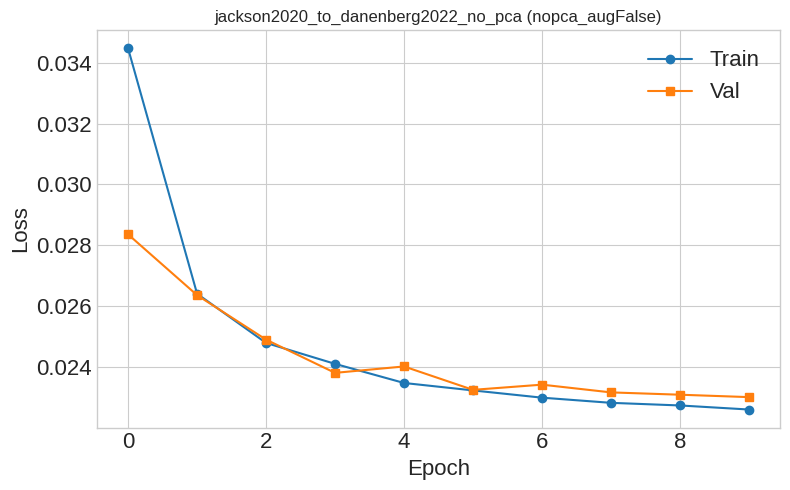

[cache] Saved model to /kaggle/working/cv_cache/model_jackson2020_to_danenberg2022_no_pca_nopca_augFalse.pth

========== EVAL [nopca_augFalse] marker=c_erb_b_2_her2 ==========


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  RMSE=0.2078  Pearson=0.3160  FID=224.26

========== EVAL [nopca_augFalse] marker=cd20 ==========


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  RMSE=0.2297  Pearson=0.2397  FID=189.68

========== EVAL [nopca_augFalse] marker=cd3 ==========


...

  RMSE=0.1401  Pearson=0.1832  FID=167.77

========== EVAL [nopca_augFalse] marker=pan_cytokeratin ==========


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  RMSE=0.2363  Pearson=0.3851  FID=260.10

========== EVAL [nopca_augFalse] marker=sma ==========


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  RMSE=0.1442  Pearson=0.3753  FID=241.32


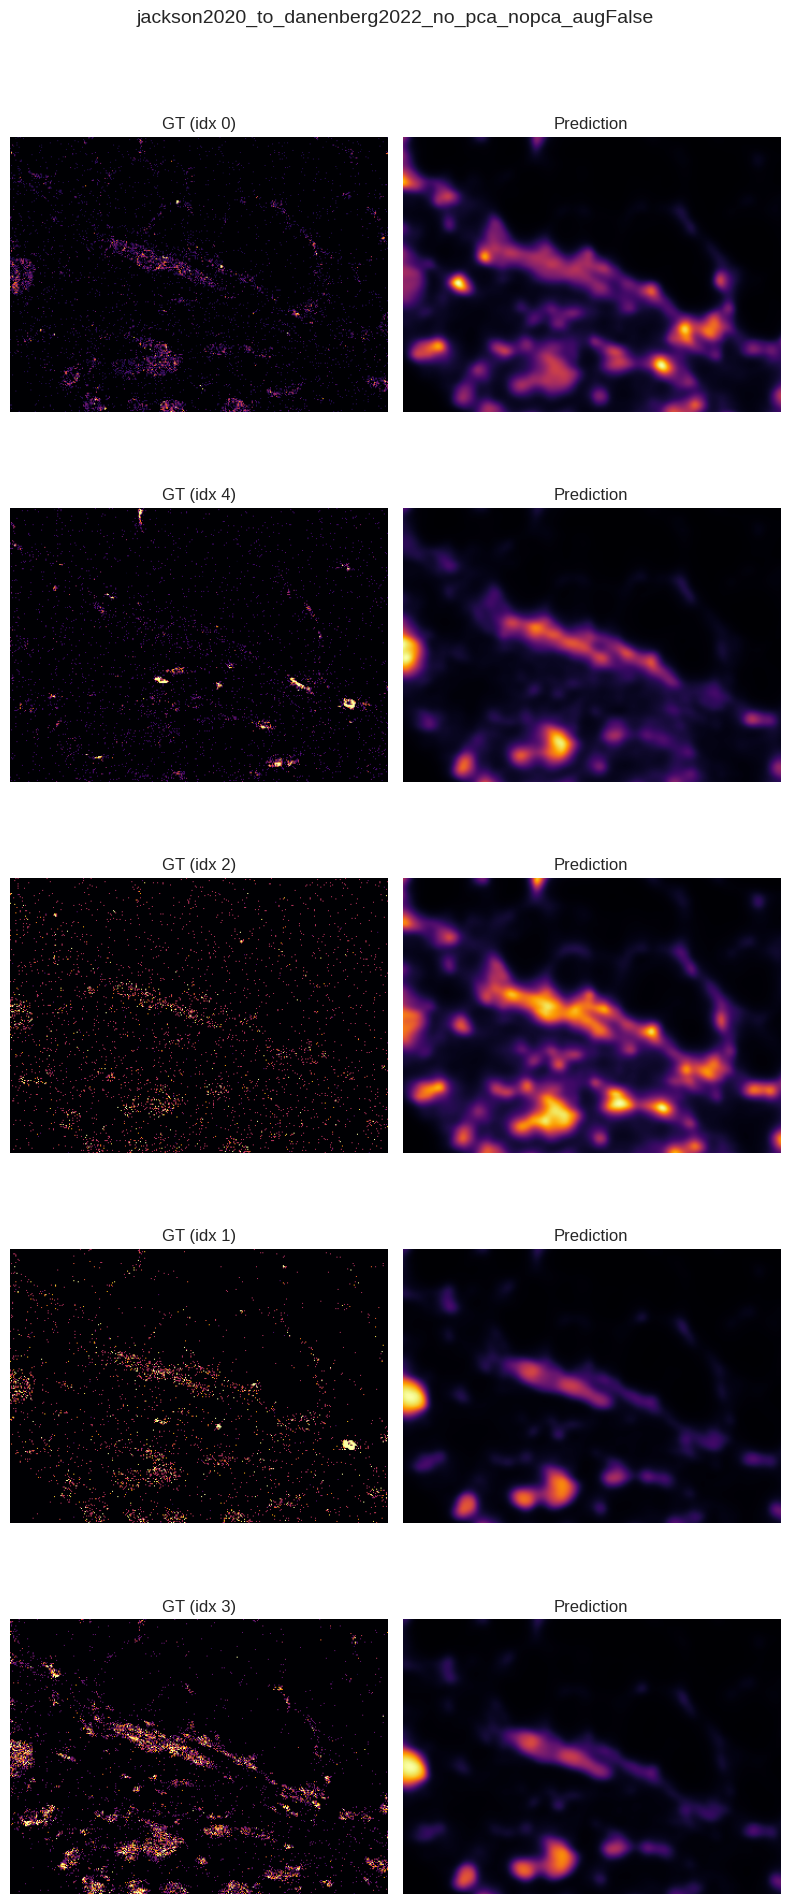

[vis] Saved comparison_jackson2020_to_danenberg2022_no_pca_nopca_augFalse.png
Finished condition [no_pca] in 366.5 min

CONDITION: no_pca_aug
[split] Train: 735, External test: 794
[split] train items=6061 (551 files × 11 tasks), val items=2024 (184 files × 11 tasks, aug=False)
[split] test items=8734 (aug=False)
[model] no_pca Conv2d(K=10, 64, 7×7)  stem params: 31,360
[train] Training nopca_augTrue on 11 tasks jointly


In [11]:
# ─── Experiment configuration ─────────────────────────────────────────────────
#
# 2×2 design — architecture (no_pca vs hyperconv) × augmentation (off / on).
# One model trained per condition (4 total); each model is jointly trained on
# all 11 marker-prediction tasks so embeddings are shared across tasks.

# ── Build task list ────────────────────────────────────────────────────────────
# Input channels sorted by Jackson index for each task → no_pca channel positions
# are consistent across tasks; hyperconv uses marker_ids to identify them.
shared_non_ctrl = [m for m in shared_markers if m not in set(control_names)]
all_tasks = [
    (j_idx[m], sorted([j_idx[mm] for mm in shared_non_ctrl if mm != m]))
    for m in shared_non_ctrl
]
task_names = shared_non_ctrl
print(f'Tasks (n={len(all_tasks)}): {task_names}')
print(f'K (input channels per task) = {len(all_tasks[0][1])}')

# ── Fit channel preprocessing ONCE (shared across all 4 conditions) ──────────
all_pred_ch = sorted({idx for _, inp in all_tasks for idx in inp})
preproc_cache_path = os.path.join(WORK_CACHE_ROOT, 'channel_preproc_v2.pkl')
resume = True

if resume and os.path.exists(preproc_cache_path):
    with open(preproc_cache_path, 'rb') as fp:
        channel_preproc, target_norm_stats = pickle.load(fp)
    print(f'[prepro] Loaded from {preproc_cache_path}')
else:
    # Search recursively so nested Kaggle dataset structures are found
    train_files_all = sorted(set(
        glob.glob(os.path.join(train_path, '*.tif')) +
        glob.glob(os.path.join(train_path, '*.tiff')) +
        glob.glob(os.path.join(train_path, '**', '*.tif'),  recursive=True) +
        glob.glob(os.path.join(train_path, '**', '*.tiff'), recursive=True)
    ))
    print(f'[prepro] Found {len(train_files_all)} training files under {train_path}')
    if not train_files_all:
        raise FileNotFoundError(
            f'No .tif/.tiff files found under {train_path!r}.\n'
            f'Top-level contents: {os.listdir(train_path)[:20]}'
        )
    channel_preproc, target_norm_stats = fit_channel_preprocessing(
        train_files_all, all_pred_ch, control_train, cofactor=5.0)
    with open(preproc_cache_path, 'wb') as fp:
        pickle.dump((channel_preproc, target_norm_stats), fp)
    print(f'[prepro] Saved to {preproc_cache_path}')

# ── Run 4 conditions ──────────────────────────────────────────────────────────
conditions = [
    {'label': 'no_pca',        'use_hyperconv': False, 'augment': False},
    {'label': 'no_pca_aug',    'use_hyperconv': False, 'augment': True},
    {'label': 'hyperconv',     'use_hyperconv': True,  'augment': False},
    {'label': 'hyperconv_aug', 'use_hyperconv': True,  'augment': True},
]

# ── Apply POC_MODE settings ────────────────────────────────────────────────────
bs  = poc_cfg['batch_size']  if POC_MODE else 2
nw  = poc_cfg['num_workers'] if POC_MODE else 0
ep  = poc_cfg['epochs']      if POC_MODE else 30
pat = poc_cfg['patience']    if POC_MODE else 8
lrp = poc_cfg['lr_patience'] if POC_MODE else 5
if POC_MODE:
    print(f'[poc] batch_size={bs}  num_workers={nw}  epochs={ep}  patience={pat}  lr_patience={lrp}')

all_results = []

for cond in conditions:
    print(f"\n{'='*25}")
    print(f"CONDITION: {cond['label']}")
    print(f"{'='*25}")
    t0 = time.time()

    per_marker = main_multitask(
        path=train_path,
        tasks=all_tasks,
        task_names=task_names,
        channel_preproc=channel_preproc,
        target_norm_stats=target_norm_stats,
        control_indices=control_train,
        data_name=f'{train_dataset}_to_{test_dataset}_{cond["label"]}',
        cache_dir=WORK_CACHE_ROOT,
        batch_size=bs,
        num_workers=nw,
        epochs=ep,
        patience=pat,
        lr_patience=lrp,
        cofactor=5.0,
        test_path=test_path,
        test_index_map=train_to_test_index_map,
        use_hyperconv=cond['use_hyperconv'],
        augment=cond['augment'],
        marker_vocab_size=len(j_markers),
    )

    elapsed = (time.time() - t0) / 60
    print(f"Finished condition [{cond['label']}] in {elapsed:.1f} min")

    for marker, m in per_marker.items():
        all_results.append({
            'condition': cond['label'],
            'marker':    marker,
            'rmse':      m['rmse'],
            'pearson':   m['pearson'],
            'fid':       m['fid'],
        })
    torch.cuda.empty_cache(); gc.collect()

# ─── Summary ──────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
for metric in ['rmse', 'pearson', 'fid']:
    print(f"\n--- {metric.upper()} ---")
    pivot = results_df.pivot_table(index='marker', columns='condition', values=metric)
    ordered = [c['label'] for c in conditions if c['label'] in pivot.columns]
    print(pivot[ordered].round(4).to_string())

out_csv = os.path.join(WORK_CACHE_ROOT, 'hyperconv_experiment_results.csv')
results_df.to_csv(out_csv, index=False)
print(f"\n[saved] {out_csv}")